# Milestone 2.2 Validation — Plant Sterols (Ras 2014)

Validates the dose-response model (`src/model_v1.py`) on plant sterols data.

**Questions answered:**
1. Does the model converge (R-hat < 1.01, ESS > 400)?
2. Does the posterior dose curve recover Ras 2014 reported per-dose effects?
3. What is the predicted final LDL for a concrete example patient?

**Data**: Ras 2014 (PMID 24780090), 6 dose bins, 0.6–3.3 g/day, unit = percent.

**Prior rationale**: At mean dose (~1.9 g/day), Ras reports ~-8% LDL reduction.
alpha_mu = -8.0, alpha_sd = 2.5 (3× the ~0.8% CI half-width at nearby doses).

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from src.data_loader import load_intervention
from src.model_v1 import build_model, sample_model, predict

az.style.use('arviz-darkgrid')

# User inputs for the prediction example
DOSE_QUERY   = 2.0   # g/day
BASELINE_LDL = 150.0 # mg/dL

print('Imports OK')

Imports OK


---
## Section 1 — Load Data

In [2]:
data = load_intervention('plant_sterols')

print(f"n_studies : {data['n_studies']}")
print(f"mean_dose : {data['mean_dose']:.2f} g/day")
print()
print(f"{'label':<22} {'dose':>6} {'dose_c':>8} {'y_obs':>7} {'se':>6}")
for i, lab in enumerate(data['labels']):
    print(f"{lab:<22} {data['dose_raw'][i]:>6.1f} {data['dose_c'][i]:>8.2f} "
          f"{data['y_obs'][i]:>7.1f} {data['se'][i]:>6.3f}")

n_studies : 6
mean_dose : 1.90 g/day

label                    dose   dose_c   y_obs     se
RAS_2014_dose1            0.6    -1.30    -5.7  0.689
RAS_2014_dose2            1.1    -0.80    -6.4  0.918
RAS_2014_dose3            1.7    -0.20    -7.6  0.408
RAS_2014_dose4            2.1     0.20    -8.4  0.408
RAS_2014_dose5            2.6     0.70   -10.3  0.740
RAS_2014_dose6            3.3     1.40   -12.4  0.612


---
## Section 2 — Build and Sample Model

In [ ]:
model = build_model(
    data         = data,
    alpha_mu     = -8.0,   # prior: effect at mean dose (~1.9 g/day)
    alpha_sd     = 2.5,    # 3x CI half-width — wide enough to let data dominate
    mode         = 'dose_response',  # Ras 2014: continuous dose range, single paper
)

idata = sample_model(model, random_seed=42)

---
## Section 3 — Convergence Diagnostics

Pass criteria: R-hat < 1.01, ESS bulk > 400, ESS tail > 400, divergences = 0.

In [4]:
summary = az.summary(idata, var_names=['alpha', 'beta'], round_to=3)
print(summary)

n_div = idata.sample_stats['diverging'].values.sum()
print(f'\nDivergences: {n_div}')
print('R-hat OK:', (summary['r_hat'] < 1.01).all())

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -8.294  0.221  -8.696   -7.866      0.003    0.002  6828.678  5465.070   
beta  -2.478  0.301  -3.051   -1.917      0.004    0.004  6427.583  5095.961   

       r_hat  
alpha    1.0  
beta     1.0  

Divergences: 0
R-hat OK: True


/var/folders/yt/rnnt0v_s18sfbxn494tglqdc0000gn/T/ipykernel_4772/2190713993.py:3: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


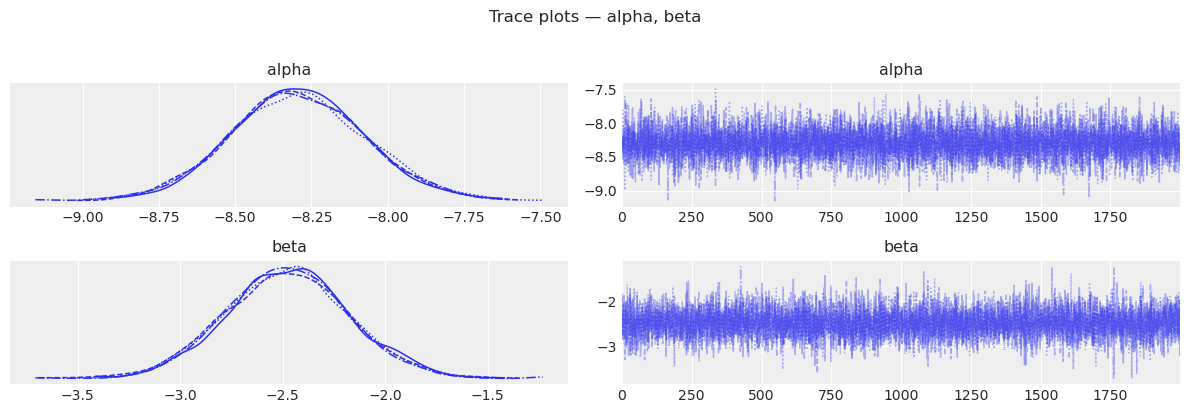

In [5]:
az.plot_trace(idata, var_names=['alpha', 'beta'], compact=True)
plt.suptitle('Trace plots — alpha, beta', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4 — Dose-Response Curve

Posterior mean curve + 95% CrI band, overlaid on Ras 2014 observed values.

Validation check: do the observed points fall within the posterior band?
Pay attention to the high-dose end (3.3 g/day) — linear model may overestimate
if the true curve saturates.

/var/folders/yt/rnnt0v_s18sfbxn494tglqdc0000gn/T/ipykernel_4772/1421229238.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


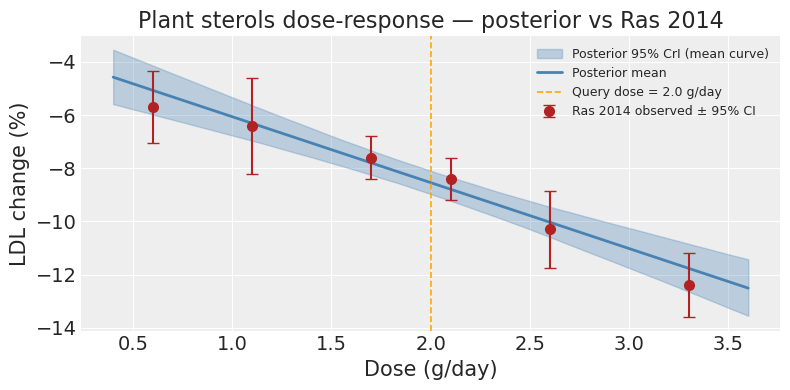

In [6]:
alpha_samples = idata.posterior['alpha'].values.flatten()
beta_samples  = idata.posterior['beta'].values.flatten()
mean_dose     = data['mean_dose']

# Posterior curve over a fine dose grid
dose_grid = np.linspace(0.4, 3.6, 100)
dose_grid_c = dose_grid - mean_dose

# Shape: (n_samples, n_grid)
curve_samples = alpha_samples[:, None] + beta_samples[:, None] * dose_grid_c[None, :]
curve_mean = curve_samples.mean(axis=0)
curve_lo   = np.percentile(curve_samples, 2.5, axis=0)
curve_hi   = np.percentile(curve_samples, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))

# Posterior band (alpha + beta*dose, no tau — this is the mean curve)
ax.fill_between(dose_grid, curve_lo, curve_hi,
                alpha=0.3, color='steelblue', label='Posterior 95% CrI (mean curve)')
ax.plot(dose_grid, curve_mean, color='steelblue', linewidth=2, label='Posterior mean')

# Ras 2014 observed
ax.errorbar(data['dose_raw'], data['y_obs'],
            yerr=1.96 * data['se'],
            fmt='o', color='firebrick', capsize=4, markersize=7,
            label='Ras 2014 observed ± 95% CI', zorder=5)

# Query dose marker
ax.axvline(DOSE_QUERY, color='orange', linestyle='--', linewidth=1.2,
           label=f'Query dose = {DOSE_QUERY} g/day')

ax.set_xlabel('Dose (g/day)')
ax.set_ylabel('LDL change (%)')
ax.set_title('Plant sterols dose-response — posterior vs Ras 2014')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 5 — Individual Prediction

Predicted final LDL at the queried dose, computed from posterior samples
using `predict()` — no re-sampling needed.

Interval reflects uncertainty in the dose-response estimate (alpha and beta
posteriors). Because all 6 rows come from one paper, tau is not included —
the uncertainty here is "how well do we know the average dose-response curve,"
not individual variability between patients.

In [ ]:
pred = predict(idata, data, baseline_ldl=BASELINE_LDL, dose_query=DOSE_QUERY)

ldl_mean = pred['ldl_final'].mean()
ldl_lo   = np.percentile(pred['ldl_final'], 2.5)
ldl_hi   = np.percentile(pred['ldl_final'], 97.5)

effect_mean = pred['theta_new'].mean()
effect_lo   = np.percentile(pred['theta_new'], 2.5)
effect_hi   = np.percentile(pred['theta_new'], 97.5)

print(f'Baseline LDL       : {BASELINE_LDL:.0f} mg/dL')
print(f'Dose               : {DOSE_QUERY} g/day plant sterols')
print()
print(f'Predicted effect   : {effect_mean:.1f}%  95% CrI [{effect_lo:.1f}, {effect_hi:.1f}]')
print(f'Predicted LDL final: {ldl_mean:.1f} mg/dL  95% CrI [{ldl_lo:.1f}, {ldl_hi:.1f}]')

/var/folders/yt/rnnt0v_s18sfbxn494tglqdc0000gn/T/ipykernel_4772/837578643.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


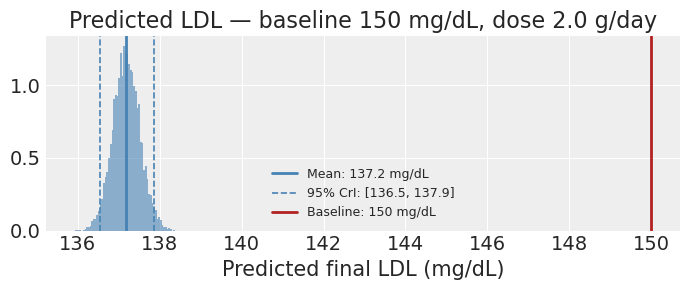

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(pred['ldl_final'], bins=60, density=True, alpha=0.6, color='steelblue')
ax.axvline(ldl_mean, color='steelblue', linewidth=2, label=f'Mean: {ldl_mean:.1f} mg/dL')
ax.axvline(ldl_lo,   color='steelblue', linewidth=1.2, linestyle='--')
ax.axvline(ldl_hi,   color='steelblue', linewidth=1.2, linestyle='--',
           label=f'95% CrI: [{ldl_lo:.1f}, {ldl_hi:.1f}]')
ax.axvline(BASELINE_LDL, color='firebrick', linewidth=2,
           label=f'Baseline: {BASELINE_LDL:.0f} mg/dL')
ax.set_xlabel('Predicted final LDL (mg/dL)')
ax.set_title(f'Predicted LDL — baseline {BASELINE_LDL:.0f} mg/dL, dose {DOSE_QUERY} g/day')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()